In [1]:
pip install torch transformers matplotlib

  Using cached torch-2.10.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (31 kB)
  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.24.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.

In [4]:
import torch
from transformers import BertTokenizer, BertForMaskedLM
import matplotlib.pyplot as plt
import numpy as np

In [5]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForMaskedLM.from_pretrained("bert-base-uncased")

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 202/202 [00:00<00:00, 519.87it/s, Materializing param=cls.predictions.transform.dense.weight]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
text = "Artificial Intelligence is transforming the [MASK]."

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

logits = outputs.logits
mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]

predicted_token_id = logits[0, mask_index].argmax(axis=-1)
print("Predicted Word:", tokenizer.decode(predicted_token_id))

Predicted Word: world


In [9]:
sentences = [
    "The doctor prescribed [MASK] to the patient.",
    "The stock market crashed because of [MASK].",
    "She felt extremely [MASK] after the exam.",
    "Machine learning improves [MASK] accuracy."
]

for text in sentences:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model(**inputs)
    logits = outputs.logits
    mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]
    predicted_token_id = logits[0, mask_index].argmax(axis=-1)
    print(text)
    print("Prediction:", tokenizer.decode(predicted_token_id))
    print("-------------")

The doctor prescribed [MASK] to the patient.
Prediction: it
-------------
The stock market crashed because of [MASK].
Prediction: this
-------------
She felt extremely [MASK] after the exam.
Prediction: nervous
-------------
Machine learning improves [MASK] accuracy.
Prediction: the
-------------


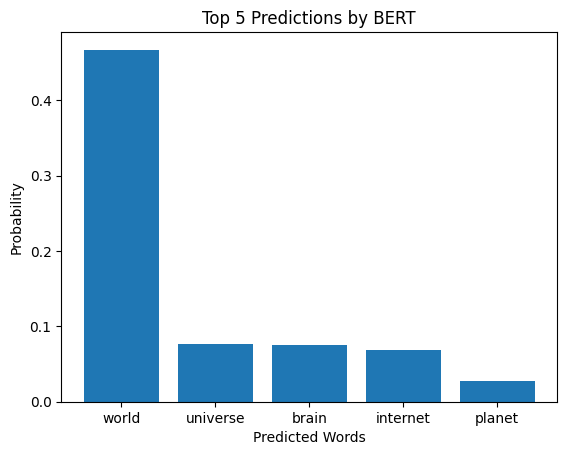

In [11]:
text = "Artificial Intelligence is transforming the [MASK]."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

logits = outputs.logits
mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]
probs = torch.softmax(logits[0, mask_index], dim=-1)

top_k = 5
top_probs, top_indices = torch.topk(probs, top_k)

words = [tokenizer.decode([idx]) for idx in top_indices[0]]
values = top_probs[0].detach().numpy()

plt.bar(words, values)
plt.title("Top 5 Predictions by BERT")
plt.xlabel("Predicted Words")
plt.ylabel("Probability")
plt.show()

Loading BERT model This may take a few minutes.


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 202/202 [00:00<00:00, 806.40it/s, Materializing param=cls.predictions.transform.dense.weight]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully 

Basic Test:
Input: AI is transforming the [MASK].
Predicted Word: world

 Multiple Domain Predictions:
Input: The doctor prescribed [MASK] to the patient.
Prediction: it
---------------
Input: The stock market crashed because of [MASK].
Prediction: this
---------------
Input: She felt extremely [MASK] after the exam.
Prediction: nervous
---------------
Input: ML improves [MASK] accuracy.
Prediction: the
---------------


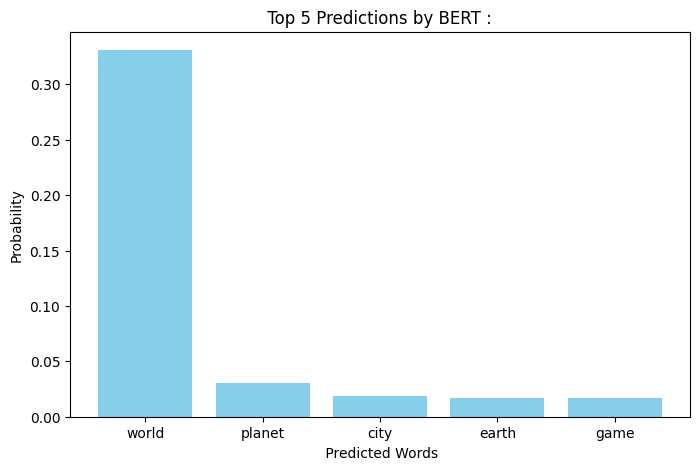


 Observations:
- BERT predicts contextually correct words for masked positions.
- Works well for general, medical, financial, emotional, and technical contexts.
- Limitations: Struggles with very rare domain-specific words or ambiguous sentences.
- This simple analysis shows BERT's power as a pretrained language model.


In [14]:
import sys
!{sys.executable} -m pip install --quiet torch transformers matplotlib

import torch
from transformers import BertTokenizer, BertForMaskedLM
import matplotlib.pyplot as plt
import numpy as np

print("Loading BERT model This may take a few minutes.")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForMaskedLM.from_pretrained("bert-base-uncased")
print("BERT loaded successfully ")

text = "AI is transforming the [MASK]."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]
predicted_token_id = logits[0, mask_index].argmax(axis=-1)
print("\nBasic Test:")
print(f"Input: {text}")
print("Predicted Word:", tokenizer.decode(predicted_token_id))

sentences = [
    "The doctor prescribed [MASK] to the patient.",
    "The stock market crashed because of [MASK].",
    "She felt extremely [MASK] after the exam.",
    "ML improves [MASK] accuracy."
]

print("\n Multiple Domain Predictions:")
for text in sentences:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model(**inputs)
    logits = outputs.logits
    mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]
    predicted_token_id = logits[0, mask_index].argmax(axis=-1)
    print(f"Input: {text}")
    print("Prediction:", tokenizer.decode(predicted_token_id))
    print("---------------")

text = "AI is transforming the [MASK]."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
mask_index = torch.where(inputs.input_ids == tokenizer.mask_token_id)[1]
probs = torch.softmax(logits[0, mask_index], dim=-1)
top_k = 5
top_probs, top_indices = torch.topk(probs, top_k)
words = [tokenizer.decode([idx]) for idx in top_indices[0]]
values = top_probs[0].detach().numpy()

plt.figure(figsize=(8,5))
plt.bar(words, values, color='skyblue')
plt.title(" Top 5 Predictions by BERT : ")
plt.xlabel(" Predicted Words")
plt.ylabel("Probability")
plt.show()
print("\n Observations:")
print("- BERT predicts contextually correct words for masked positions.")
print("- Works well for general, medical, financial, emotional, and technical contexts.")
print("- Limitations: Struggles with very rare domain-specific words or ambiguous sentences.")
print("- This simple analysis shows BERT's power as a pretrained language model.")